# Quantium Retail Analytics – Task 1

## Data Loading
We begin by importing the required libraries and loading the datasets. The transaction dataset contains product-level purchase information, while the customer dataset provides segmentation details.

In [27]:
from google.colab import files
uploaded = files.upload()

Saving QVI_purchase_behaviour.csv to QVI_purchase_behaviour (1).csv
Saving QVI_transaction_data.xlsx to QVI_transaction_data (1).xlsx


The datasets have been successfully loaded. A preview confirms the presence of key variables such as transaction date, product details, and customer segmentation attributes.

## Data Loading and Data Exploration

We begin by importing the required libraries and loading the datasets. The transaction dataset contains product-level purchase information, while the customer dataset provides segmentation details.

Next, we examine the structure of the datasets to understand data types and identify any issues.

In [28]:
import pandas as pd

transactions = pd.read_excel('QVI_transaction_data.xlsx')
customers = pd.read_csv('QVI_purchase_behaviour.csv')

print(transactions.head())
print(customers.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004  

In [29]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load files (since you uploaded via Method 1)
transactions = pd.read_excel('QVI_transaction_data.xlsx')
customers = pd.read_csv('QVI_purchase_behaviour.csv')

# Preview
print(transactions.head())
print(customers.head())

# Structure
print(transactions.info())
print(customers.info())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004  

Both datasets appear complete with no missing values. The DATE column is stored as an integer and will be converted into a proper datetime format for analysis. Both datasets appear complete with no missing values. The DATE column is currently stored as an integer and will be converted.

## Data Cleaning
The DATE column is converted into a datetime format to enable time-based analysis.

In [30]:
transactions['DATE'] = pd.to_datetime(transactions['DATE'], origin='1899-12-30', unit='D')

The DATE column has been successfully converted.

We filter the dataset to include only chip products by removing non-relevant items such as salsa.

In [31]:
transactions = transactions[~transactions['PROD_NAME'].str.lower().str.contains('salsa')]

Non-chip products have been removed.

We review summary statistics to identify anomalies.

In [32]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


An unusually high quantity (200 units) is identified as an outlier.

We remove the outlier customer to ensure realistic analysis.

In [33]:
outlier_customer = transactions[transactions['PROD_QTY'] == 200]['LYLTY_CARD_NBR'].unique()

transactions = transactions[~transactions['LYLTY_CARD_NBR'].isin(outlier_customer)]

The dataset now reflects typical retail purchasing behaviour.

## Time Series Analysis
We analyse transaction trends over time.

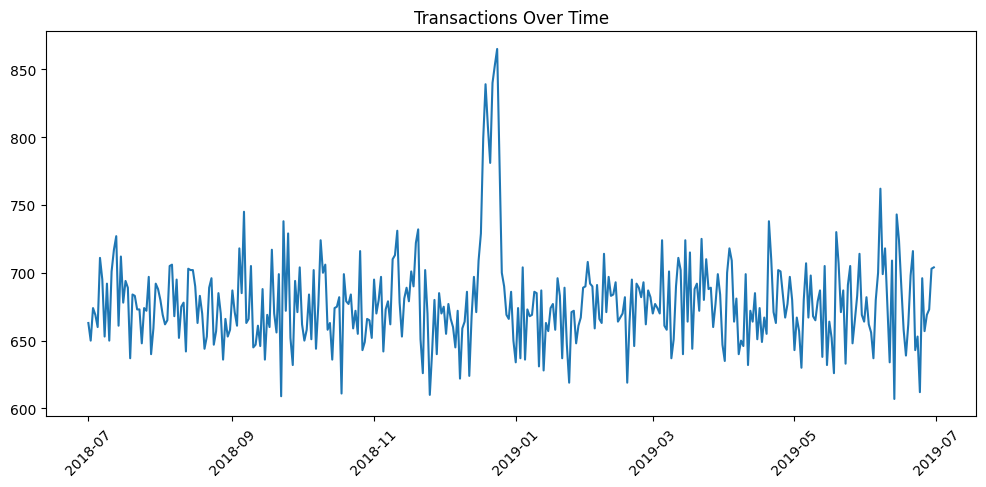

In [34]:
transactions_per_day = transactions.groupby('DATE').size().reset_index(name='COUNT')

plt.figure(figsize=(12,5))
plt.plot(transactions_per_day['DATE'], transactions_per_day['COUNT'])
plt.title('Transactions Over Time')
plt.xticks(rotation=45)
plt.show()

Transactions peak in December, indicating seasonal demand, with a drop on Christmas Day due to store closures.

## Feature Engineering
We extract pack size from product names.

In [35]:
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_12499/3466836586.py:1: SyntaxWarning: invalid escape sequence '\d'
  transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract('(\d+)').astype(float)


Pack size extraction is complete.

We examine pack size distribution.

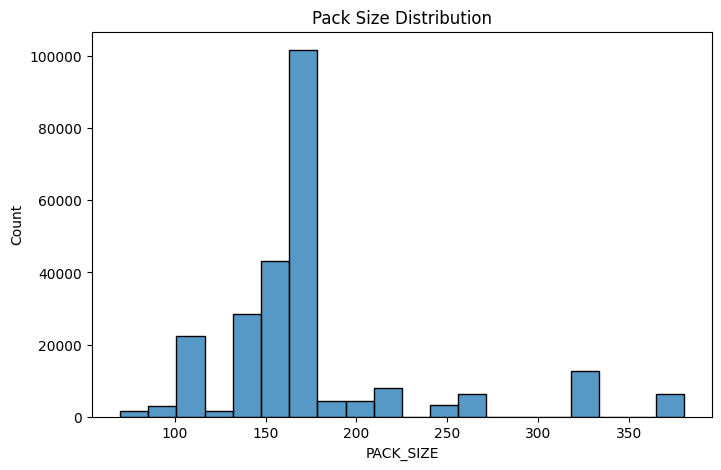

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(transactions['PACK_SIZE'], bins=20)
plt.title('Pack Size Distribution')
plt.show()

Most purchases fall between 150g–175g, with larger packs indicating family consumption.

We extract and clean brand names.

In [37]:
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]

transactions['BRAND'] = transactions['BRAND'].replace({
    'RED': 'RRD',
    'SNBTS': 'SUNBITES',
    'INFZNS': 'INFUZIONS'
})

Brand names are standardised for analysis.

## Data Integration
We merge transaction and customer datasets.

In [38]:
data = pd.merge(transactions, customers, on='LYLTY_CARD_NBR', how='left')

# Check nulls
print(data.isnull().sum())

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


The merged dataset contains no missing values.

## Customer Segment Analysis
We create key metrics for analysis.

In [39]:
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']

Metrics are ready for segmentation analysis.

### Total Sales by Segment

In [40]:
sales_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

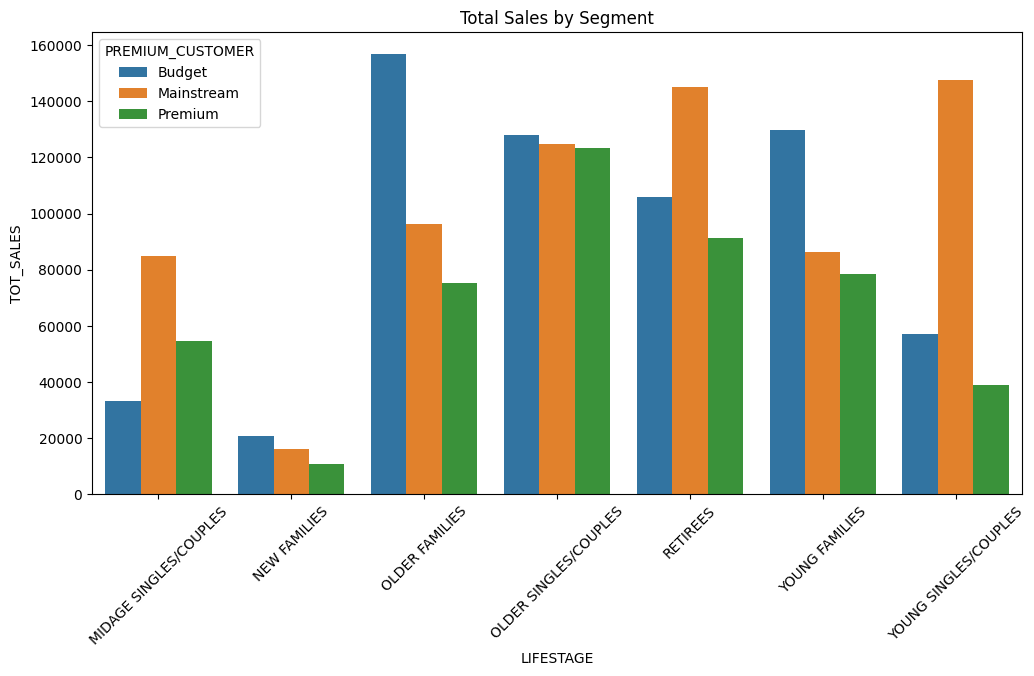

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(data=sales_segment, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title('Total Sales by Segment')
plt.show()

Mainstream young singles/couples and budget older families contribute the highest sales.

### Customers by Segment

In [42]:
customers_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
customers_segment.rename(columns={'LYLTY_CARD_NBR': 'NUM_CUSTOMERS'}, inplace=True)

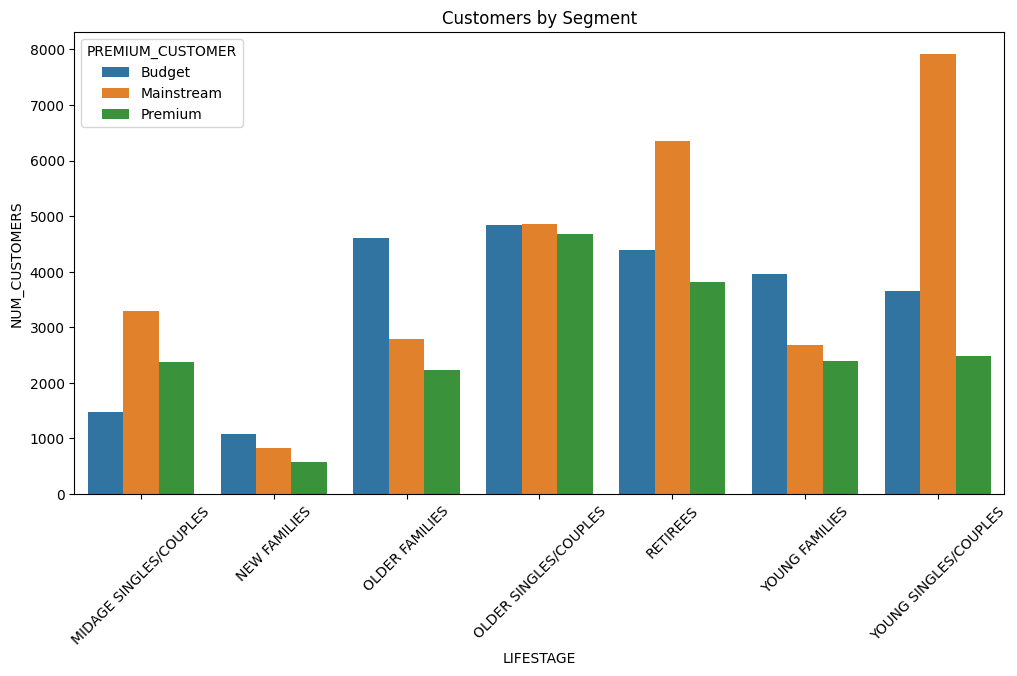

In [43]:
plt.figure(figsize=(12,6))
sns.barplot(data=customers_segment, x='LIFESTAGE', y='NUM_CUSTOMERS', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title('Customers by Segment')
plt.show()

Mainstream segments dominate in customer count.

### Units per Customer

In [44]:
units = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg({
    'PROD_QTY': 'sum',
    'LYLTY_CARD_NBR': 'nunique'
}).reset_index()

units['AVG_UNITS_PER_CUSTOMER'] = units['PROD_QTY'] / units['LYLTY_CARD_NBR']

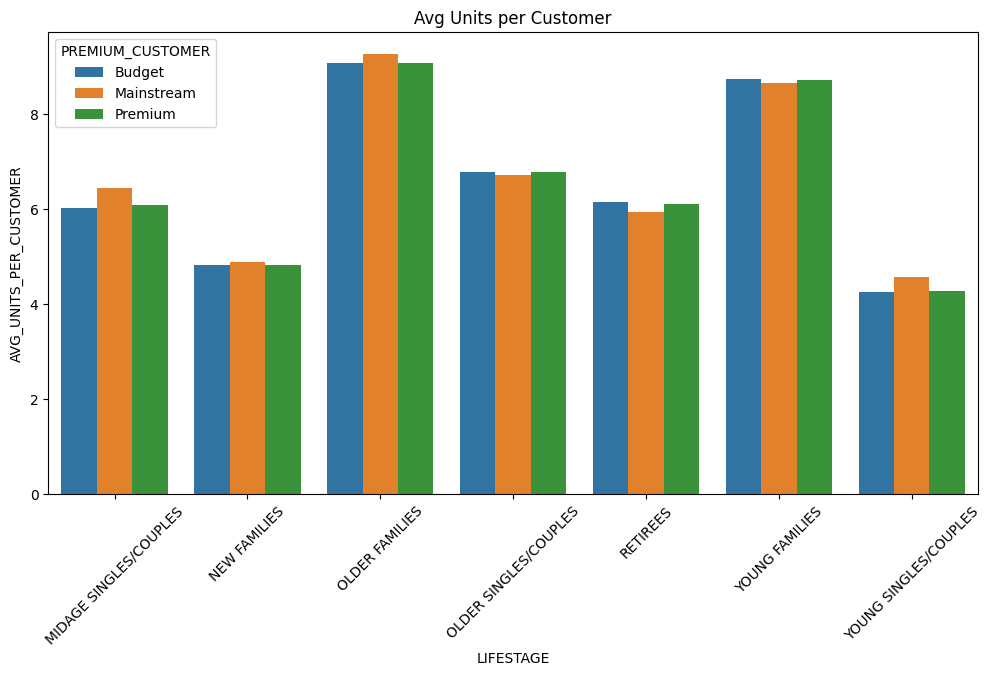

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(data=units, x='LIFESTAGE', y='AVG_UNITS_PER_CUSTOMER', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title('Avg Units per Customer')
plt.show()

Families purchase the highest number of units, indicating bulk buying behaviour.

### Price per Unit

In [46]:
price_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().reset_index()

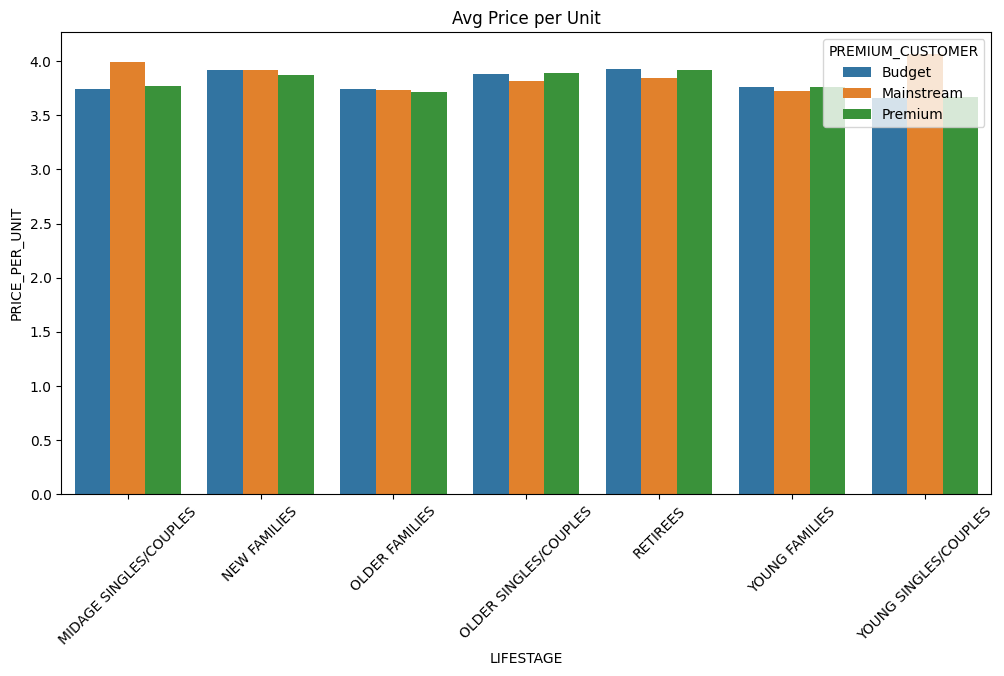

In [47]:
plt.figure(figsize=(12,6))
sns.barplot(data=price_segment, x='LIFESTAGE', y='PRICE_PER_UNIT', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title('Avg Price per Unit')
plt.show()

Price differences are minimal across segments, suggesting behaviour drives sales.

## Deep Dive: Target Segment
We focus on Mainstream Young Singles/Couples.

In [48]:
target = data[
    (data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
]

others = data.drop(target.index)

This segment is selected due to its strong contribution to sales.

### Brand Affinity

In [49]:
target_brand = target['BRAND'].value_counts(normalize=True)
other_brand = others['BRAND'].value_counts(normalize=True)

brand_affinity = pd.concat([target_brand, other_brand], axis=1)
brand_affinity.columns = ['Target', 'Other']
brand_affinity['Affinity'] = brand_affinity['Target'] / brand_affinity['Other']

brand_affinity.sort_values(by='Affinity', ascending=False).head()

,Target,Other,Affinity
BRAND,,,
Tyrrells,0.031672,0.025630,1.235751
Twisties,0.046050,0.037650,1.223096
Dorito,0.015503,0.012676,1.223031
Doritos,0.106222,0.087876,1.208774
Tostitos,0.045538,0.037769,1.205700


This segment shows stronger preference for popular and flavour-driven brands.

### Pack Size Preference

In [50]:
target_pack = target['PACK_SIZE'].value_counts(normalize=True)
other_pack = others['PACK_SIZE'].value_counts(normalize=True)

pack_affinity = pd.concat([target_pack, other_pack], axis=1)
pack_affinity.columns = ['Target', 'Other']
pack_affinity['Affinity'] = pack_affinity['Target'] / pack_affinity['Other']

pack_affinity.sort_values(by='Affinity', ascending=False).head()

,Target,Other,Affinity
PACK_SIZE,,,
270.0,0.031723,0.024934,1.272269
380.0,0.032030,0.025485,1.256849
330.0,0.061144,0.049935,1.224477
134.0,0.118451,0.100297,1.181003
210.0,0.029472,0.025071,1.175546


Preference for smaller to mid-sized packs suggests convenience-driven purchasing.

## Output

In [51]:
data.to_csv('cleaned_data.csv', index=False)

The dataset is saved for further analysis.
